# Climate Adaptation Funding: Analysis of Adaptation Fund Projects

**Course:** DATASCI 530 - Computing I  
**Name:** Tanya Jagdish 

**Data Source:** [Adaptation Fund Projects Database](https://www.adaptation-fund.org/projects-programmes/project-information/projects-table-view/)

## <span style="color:darkblue"> Executive Summary </span>

**About the Adaptation Fund:**
- This report analyzes **181 climate adaptation projects** funded by the Adaptation Fund to understand global patterns in climate adaptation funding, sectoral priorities, and geographic distribution. 
- The Adaptation Fund is an international climate finance mechanism that funds concrete adaptation projects in developing countries vulnerable to climate change

**Objectives of this report:**
Analyze Adaptation Fund projects to answer three main questions:

1. What are the most common themes in climate adaptation projects? (analyzed through project title word frequency)
2. Which countries and regions receive the most adaptation funding, and how has this changed over time?
3. What sectors (agriculture, water, coastal, multi-sector) are prioritized, and how have these priorities evolved?

Note: Data was collected on October 22, 2025. For more information on data collection methodology, please see Project 1 report

**Key Findings:**

1. **Community-Centered Resilience Focus:** Analysis of 181 adaptation projects reveals a strong emphasis on community-level resilience building, with "resilience," "communities," and "enhancing" as the most prominent themes, demonstrating a people-centered rather than infrastructure-driven approach to climate adaptation.

2. **Geographic Disparities in Funding Allocation:** Asia-Pacific leads in project volume (63 projects) while Africa receives the highest total funding ($380M), suggesting regional differences in project scale and climate vulnerability. Eastern Europe remains significantly underrepresented with only 11 projects and $70M in funding.

3. **Multi-Sector Integration Dominates:** Multi-sector projects account for the largest share of both projects (27) and funding ($240M), reflecting a strategic shift toward integrated adaptation approaches. However, Food Security receives the highest total funding ($280M) despite fewer projects, indicating larger-scale investments in this critical sector.

4. **Sustained but Variable Funding Momentum:** After peaking at $177.7M in 2019, funding has stabilized at $85-157M annually (2020-2025), with consistent project approval rates (9-20 projects per year). Regional distribution patterns remain stable over time, with Asia-Pacific and Africa consistently dominating the portfolio.

---
## <span style="color:darkblue"> Table of Contents </span>

1. [Import Libraries and Load Dataset](#1-import-libraries-and-load-dataset)
2. [Data Cleaning and Preparation](#2-data-cleaning-and-preparation)
3. [Analysis](#3-analysis)
   - [Q1: What are the Most Common Words in Project Titles?](#q1-what-are-the-most-common-words-in-project-titles)
   - [Q2: Which Countries and Regions Receive the Most Adaptation Funding? How Has This Changed Over Time?](#q2-which-countries-and-regions-receive-the-most-adaptation-funding-how-has-this-changed-over-time)
   - [Q3: What Sectors Are Prioritized?](#q3-what-sectors-are-prioritized)
4. [Discussion and Conclusions](#2-discussion-and-conclusions)

---
## <span style="color:darkblue"> 1. Import libraries and load dataset </span>

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datetime import datetime

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 5)
pd.set_option('display.float_format', lambda x: '${:,.2f}'.format(x) if abs(x) >= 1 else '{:.4f}'.format(x))

# Load the dataset
adaptation_project = pd.read_csv('data_clean/adaptation_fund_projects_clean.csv')

# Display basic information

print("DATASET OVERVIEW")

print(f"\nTotal number of projects: {len(adaptation_project)}")
print(f"Number of features: {adaptation_project.shape[1]}")

DATASET OVERVIEW

Total number of projects: 181
Number of features: 18


**AI note:**
I used Claude to help identify the best package to install to improve vizualization style (i.e., seaborne) and also to help set the display style for numbers across the entire notebook

---
## <span style="color:darkblue"> 2. Data cleaning and preparation
 </span>

Data cleaning includes:
- Split 'country_region' column to separate 'country' and 'region' columns
    - Current state example value: "Ethiopia/Africa" 
- Create 'project_type' column from 'country_region' column
    - Why: There are some projects that are classified as "Regional/Other" since they span multiple countries
    - The goal is to classify each project as "regional" if it says "Regional/Other" and national if there's a country specified
- Convert 'approval_date' column to datetime format and extract year for temporal analysis
    - Why: Currently, all the date columns are stored as texts in the format of "mm/dd/yyyy"
- Clean and convert monetary values under 'grant_amount'
    - Why: Currently, all monetary values are stored as texts in the format "USD 10,000"
- Clean 'sector' column
    - Some entries have newline characters in them
    - The goal is to remove newlines with spaces and remove extra whitespace


In [53]:
# Split country_region into separate columns
adaptation_project[['country', 'region']] = adaptation_project['country_region'].str.split('/', expand=True)

# Convert approval_date to datetime and extract year
adaptation_project['approval_date'] = pd.to_datetime(adaptation_project['approval_date'])
adaptation_project['approval_year'] = adaptation_project['approval_date'].dt.year

# Clean sector column
adaptation_project['sector'] = adaptation_project['sector'].str.replace('\n', ' ')
adaptation_project['sector'] = adaptation_project['sector'].str.strip()

# Create project_type column
adaptation_project['project_type'] = adaptation_project['country'].apply(
    lambda x: 'Regional' if x == 'Regional' else 'National'
)

# Display cleaned data sample
# adaptation_project[['project_name', 'country', 'region', 'sector', 'approval_year', 'project_type']].head()

#save cleaned dataset
adaptation_project.to_csv('data_clean/adaptation_fund_projects_cleaned_project2.csv', index=False)

---
## <span style="color:darkblue"> 3. Analysis
 </span>

### <span style="color:darkblue"> Q1. What are the most common words in Project Titles? </span>

Understanding the most frequently used words in project titles helps identify key themes and priorities in climate adaptation projects.

Total number of projects analyzed: 181



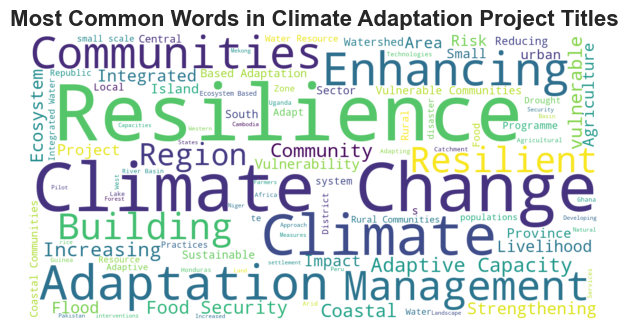

In [10]:
# Display total number of projects
print(f"Total number of projects analyzed: {len(adaptation_project)}\n")

# Combine all project titles into one text string
all_titles = ' '.join(adaptation_project['project_name'].dropna())

# Create word cloud
wordcloud = WordCloud(width=1200, height=600, 
                      background_color='white',
                      colormap='viridis',
                      max_words=100).generate(all_titles)

# Display word cloud
plt.figure(figsize=(6, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Climate Adaptation Project Titles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights:**
- **Dominant Themes:** The most prominent words are "Resilience," "Communities," "Climate Change," and "Enhancing," indicating that adaptation projects primarily focus on building resilience at the community level
- **Action-Oriented Language:** Strong presence of action verbs like "Enhancing," "Building," "Increasing," and "Strengthening" suggests projects emphasize proactive capacity building
- **Key Focus Areas:** Frequently mentioned terms include "Adaptation," "Capacity," "Management," "Food Security," and "Coastal," highlighting the main sectors and approaches in climate adaptation work
- **Community-Centered Approach:** The emphasis on "Communities," "Vulnerable," and "Livelihood" demonstrates a people-centered approach targeting vulnerable populations


### <span style="color:darkblue"> Q2. Which countries and regions receive the most adaptation funding? How has this changed over time? </span>

Understanding the geographic distribution of funding helps identify where climate adaptation resources are being allocated and whether funding patterns have shifted over time.

#### (a) Regional Distribution of Adaptation Projects and Funding

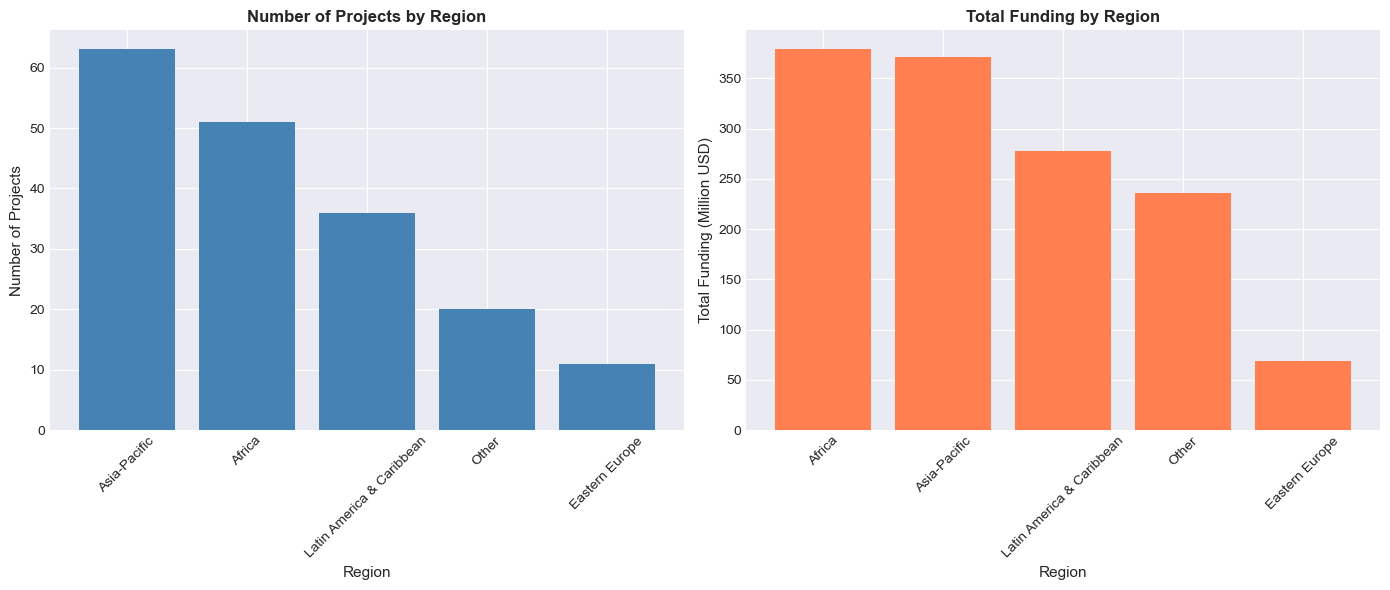

In [23]:
# Calculate regional statistics
region_projects = adaptation_project['region'].value_counts().sort_values(ascending=False)
region_funding = adaptation_project.groupby('region')['grant_amount_clean'].sum().sort_values(ascending=False) / 1e6

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Number of projects by region
ax1.bar(region_projects.index, region_projects.values, color='steelblue')
ax1.set_xlabel('Region', fontsize=11)
ax1.set_ylabel('Number of Projects', fontsize=11)
ax1.set_title('Number of Projects by Region', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Total funding by region
ax2.bar(region_funding.index, region_funding.values, color='coral')
ax2.set_xlabel('Region', fontsize=11)
ax2.set_ylabel('Total Funding (Million USD)', fontsize=11)
ax2.set_title('Total Funding by Region', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Key Insights:
- **Regional Leaders:** Asia-Pacific leads in number of projects (63 projects), while Africa receives the highest total funding (~$380 million), suggesting African projects receive larger average grants
- **Funding Disparities:** Despite having fewer projects than Asia-Pacific, Africa secures more funding, indicating a focus on larger-scale, more resource-intensive adaptation initiatives in the region
- **Three Major Recipients:** Asia-Pacific, Africa, and Latin America & Caribbean collectively account for the vast majority of both projects and funding, reflecting global climate vulnerability patterns
- **Project Scale Variations:** The mismatch between project counts and funding totals across regions suggests different adaptation strategies - some regions favor many smaller projects while others implement fewer, larger-scale interventions

#### (b) Top 10 Countries by Projects and Funding

In [34]:
# Exclude "Regional" from country analysis
countries_only = adaptation_project[adaptation_project['country'] != 'Regional']

# Calculate country statistics
country_stats = countries_only.groupby('country').agg({
    'project_name': 'count',
    'grant_amount_clean': 'sum'
}).reset_index()
country_stats.columns = ['Country', 'Number of Projects', 'Total Funding (USD)']

# Sort by number of projects and get top 10
country_stats = country_stats.sort_values('Number of Projects', ascending=False).head(10)

# Format funding in millions with 2 decimal places
country_stats['Total Funding (Million USD)'] = (country_stats['Total Funding (USD)'] / 1e6).round(2)
country_stats = country_stats[['Country', 'Number of Projects', 'Total Funding (Million USD)']]

# Display table
print("Top 10 Countries by Number of Projects")
pd.options.display.float_format = '{:.2f}'.format
display(country_stats)

Top 10 Countries by Number of Projects


,Country,Number of Projects,Total Funding (Million USD)
36,Indonesia,7,11.71
35,India,6,9.86
...,...,...,...
42,Lao People's Democratic Republic,3,17.56
1,Argentina,3,19.94


#### (c) Temporal Trends: How has regional funding and number of projects changed over time?

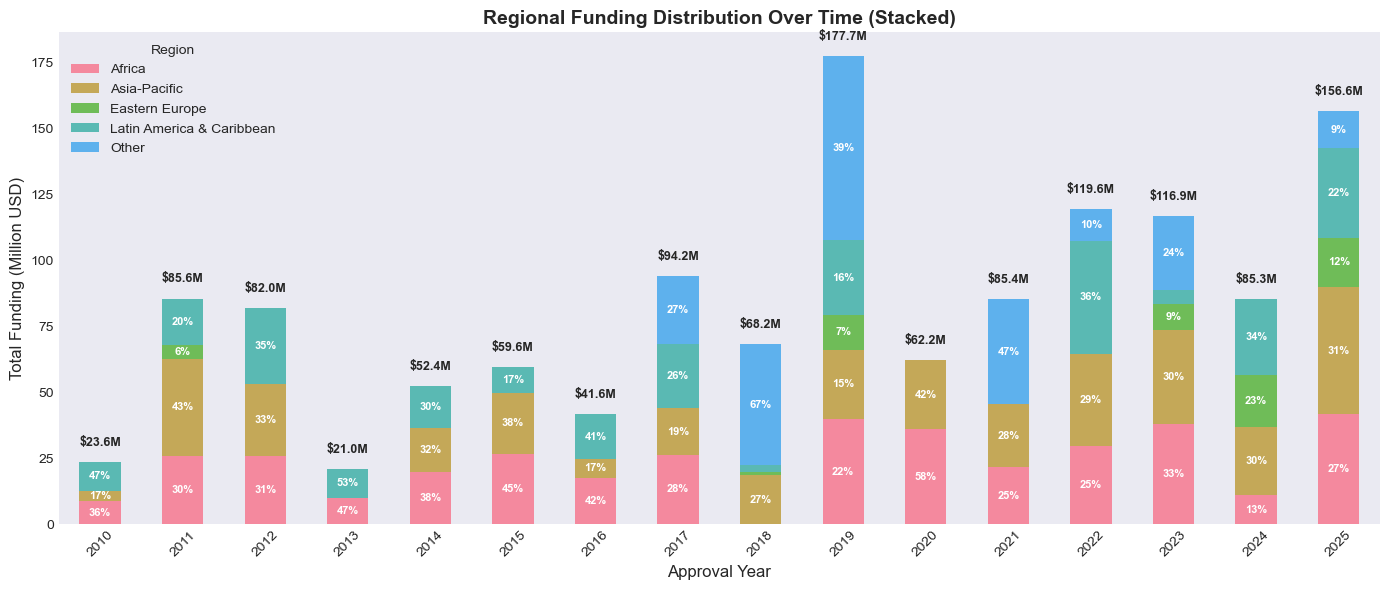

In [48]:
# Calculate funding by year and region
regional_funding_temporal = adaptation_project.groupby(['approval_year', 'region'])['grant_amount_clean'].sum().reset_index()
regional_funding_temporal['grant_amount_millions'] = regional_funding_temporal['grant_amount_clean'] / 1e6
regional_funding_pivot = regional_funding_temporal.pivot(index='approval_year', columns='region', values='grant_amount_millions').fillna(0)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
regional_funding_pivot.plot(kind='bar', stacked=True, ax=ax, alpha=0.8)

# Calculate totals for each year
yearly_totals = regional_funding_pivot.sum(axis=1)

# Add total labels on top of each bar
for i, (year, total) in enumerate(yearly_totals.items()):
    ax.text(i, total + 5, f'${total:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add percentage labels within each stack
for i, year in enumerate(regional_funding_pivot.index):
    cumulative = 0
    for region in regional_funding_pivot.columns:
        value = regional_funding_pivot.loc[year, region]
        if value > 0:  # Only show label if there's funding
            percentage = (value / yearly_totals[year]) * 100
            if percentage > 5:  # Only show percentage if segment is large enough
                ax.text(i, cumulative + value/2, f'{percentage:.0f}%', 
                       ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        cumulative += value

ax.set_xlabel('Approval Year', fontsize=12)
ax.set_ylabel('Total Funding (Million USD)', fontsize=12)
ax.set_title('Regional Funding Distribution Over Time (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Region', loc='upper left', fontsize=10)
ax.set_xticklabels(regional_funding_pivot.index, rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

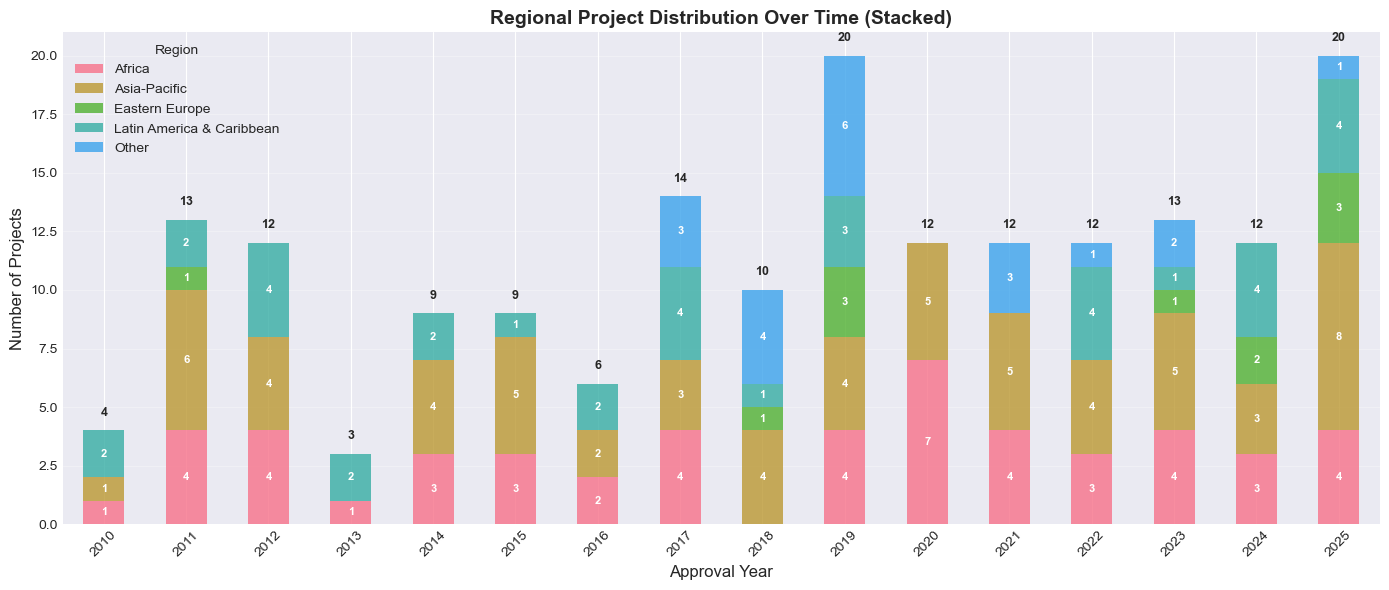

In [46]:
# Calculate projects by year and region
regional_temporal = adaptation_project.groupby(['approval_year', 'region']).size().reset_index(name='count')
regional_pivot = regional_temporal.pivot(index='approval_year', columns='region', values='count').fillna(0)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
regional_pivot.plot(kind='bar', stacked=True, ax=ax, alpha=0.8)

# Calculate totals for each year
yearly_totals = regional_pivot.sum(axis=1)

# Add total labels on top of each bar
for i, (year, total) in enumerate(yearly_totals.items()):
    ax.text(i, total + 0.5, f'{int(total)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add project count labels within each stack
for i, year in enumerate(regional_pivot.index):
    cumulative = 0
    for region in regional_pivot.columns:
        value = regional_pivot.loc[year, region]
        if value > 0:  # Only show label if there are projects
            ax.text(i, cumulative + value/2, f'{int(value)}', 
                   ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        cumulative += value

ax.set_xlabel('Approval Year', fontsize=12)
ax.set_ylabel('Number of Projects', fontsize=12)
ax.set_title('Regional Project Distribution Over Time (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Region', loc='upper left', fontsize=10)
ax.set_xticklabels(regional_pivot.index, rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Key Insights:

**Regional Funding Over Time:**
- **Peak Funding in 2019:** The Adaptation Fund reached its highest funding level at $177.7M in 2019, driven largely by the "Other" region (39%), suggesting a significant push for multi-regional or special initiative projects that year
- **Recent Stabilization:** After the 2019 peak, funding has stabilized at moderate levels ($60-120M annually from 2020-2023), with 2025 showing renewed growth to $156.6M

**Regional Project Distribution Over Time:**
- **Consistent Activity Levels:** Project approvals remain relatively steady at 9-14 projects per year (2011-2024), with notable peaks in 2019 and 2025 (20 projects each), suggesting capacity constraints in project pipeline development
- **Asia-Pacific and Africa Dominance:** These two regions consistently receive the largest share of projects across all years, reflecting their high climate vulnerability and strong institutional capacity to access adaptation finance

### <span style="color:darkblue"> Q3. What sectors are prioritized?</span>

Total number of unique sectors: 13



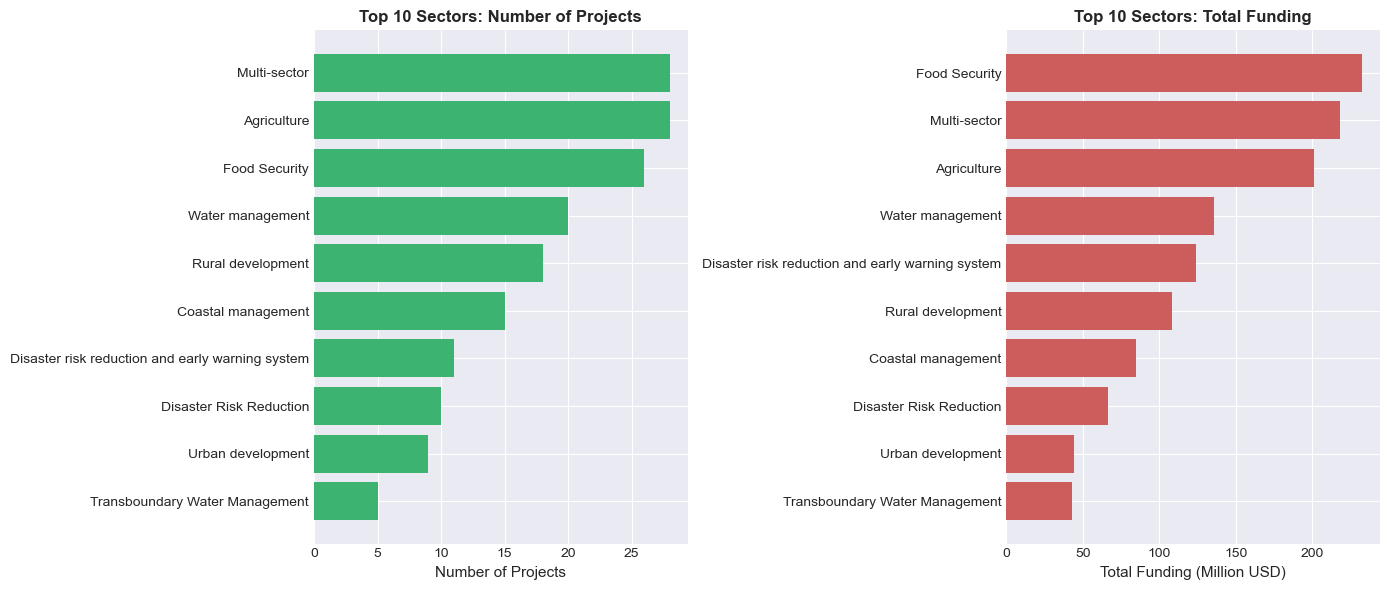

In [51]:
# Calculate sector statistics
sector_projects = adaptation_project['sector'].value_counts().head(10).sort_values(ascending=False)
sector_funding = adaptation_project.groupby('sector')['grant_amount_clean'].sum().sort_values(ascending=False).head(10) / 1e6

# Display total number of unique sectors
total_sectors = adaptation_project['sector'].nunique()
print(f"Total number of unique sectors: {total_sectors}\n")

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Number of projects by sector
ax1.barh(range(len(sector_projects)), sector_projects.values, color='mediumseagreen')
ax1.set_yticks(range(len(sector_projects)))
ax1.set_yticklabels(sector_projects.index, fontsize=10)
ax1.set_xlabel('Number of Projects', fontsize=11)
ax1.set_title('Top 10 Sectors: Number of Projects', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Plot 2: Total funding by sector
ax2.barh(range(len(sector_funding)), sector_funding.values, color='indianred')
ax2.set_yticks(range(len(sector_funding)))
ax2.set_yticklabels(sector_funding.index, fontsize=10)
ax2.set_xlabel('Total Funding (Million USD)', fontsize=11)
ax2.set_title('Top 10 Sectors: Total Funding', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

**Key Insights:**
- **Multi-sector Dominance:** Multi-sector projects lead in both project count (~27 projects) and total funding (~$240M), reflecting a strategic shift toward integrated climate adaptation approaches that address multiple vulnerabilities simultaneously
- **Food Security Priority:** Despite having fewer projects than Multi-sector and Agriculture, Food Security receives the highest total funding (~$280M), indicating larger average grant sizes for food security initiatives, likely due to their critical importance for climate-vulnerable populations
- **Agriculture and Water Focus:** Agriculture and Water management consistently rank in the top sectors for both project count and funding, highlighting their fundamental role in climate adaptation strategies globally


#### Sectoral Priorities by Project Type: Regional vs National

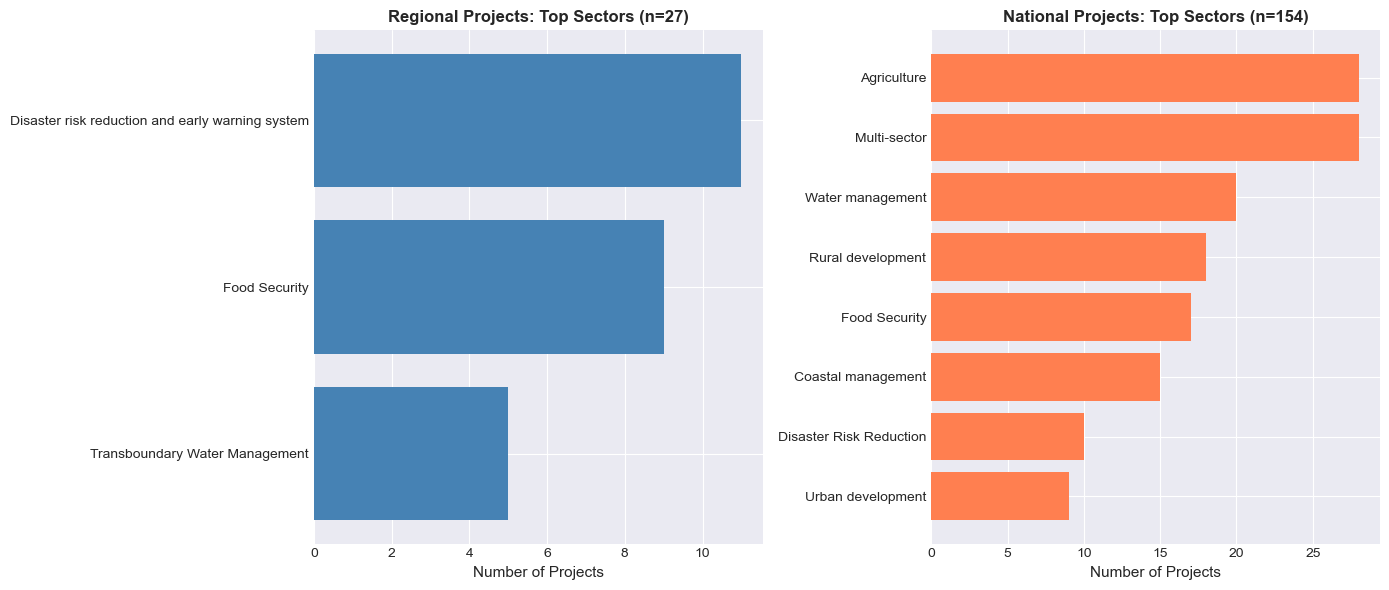

In [52]:
# Separate regional and national projects
regional_projects = adaptation_project[adaptation_project['project_type'] == 'Regional']
national_projects = adaptation_project[adaptation_project['project_type'] == 'National']

# Get top 8 sectors for each project type
regional_sectors = regional_projects['sector'].value_counts().head(8).sort_values(ascending=True)
national_sectors = national_projects['sector'].value_counts().head(8).sort_values(ascending=True)

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Regional projects by sector
ax1.barh(range(len(regional_sectors)), regional_sectors.values, color='steelblue')
ax1.set_yticks(range(len(regional_sectors)))
ax1.set_yticklabels(regional_sectors.index, fontsize=10)
ax1.set_xlabel('Number of Projects', fontsize=11)
ax1.set_title(f'Regional Projects: Top Sectors (n={len(regional_projects)})', fontsize=12, fontweight='bold')

# Plot 2: National projects by sector
ax2.barh(range(len(national_sectors)), national_sectors.values, color='coral')
ax2.set_yticks(range(len(national_sectors)))
ax2.set_yticklabels(national_sectors.index, fontsize=10)
ax2.set_xlabel('Number of Projects', fontsize=11)
ax2.set_title(f'National Projects: Top Sectors (n={len(national_projects)})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Key Insights:**
- **Regional Projects Focus on Cross-Border Challenges:** Regional (multi-country) projects heavily prioritize Disaster Risk Reduction and Early Warning Systems (~11 projects, 41% of regional portfolio), reflecting the transboundary nature of climate hazards and the value of coordinated regional response mechanisms
- **National Projects Show Greater Sectoral Diversity:** National projects are distributed across a broader range of sectors, with Agriculture (27 projects) and Multi-sector (25 projects) leading, followed by Water Management, Rural Development, and Food Security - suggesting country-specific adaptation needs drive more varied approaches
- **Transboundary Water by Design:** Transboundary Water Management appears only in regional projects (as expected), emphasizing the importance of multi-country cooperation for shared water resources affected by climate change
- **Scale Difference:** With 154 national projects versus only 27 regional projects, the Adaptation Fund primarily supports country-level interventions, though regional projects receive significant attention for addressing systemic, cross-border climate risks


---

## 4. Discussion and Conclusions

This analysis of 181 climate adaptation projects funded by the Adaptation Fund reveals critical patterns in global climate finance allocation, sectoral priorities, and geographic distribution.

### Summary of Key Findings

**1. Community-Centered Adaptation Approach**
The word cloud analysis reveals that adaptation projects emphasize "resilience," "communities," and "enhancing" capacity, demonstrating a clear focus on bottom-up, community-driven approaches rather than top-down infrastructure investments. This people-centered strategy reflects the Adaptation Fund's commitment to supporting vulnerable populations directly.

**2. Geographic Concentration with Regional Disparities**
- **Asia-Pacific** leads in project volume (63 projects), while **Africa** receives the highest total funding (~$380 million)
- This funding-to-project mismatch suggests African projects are larger in scale, potentially addressing more severe climate vulnerabilities or requiring more extensive interventions
- **Eastern Europe** remains significantly underrepresented (11 projects, $70M), indicating either lower climate vulnerability, better access to alternative funding sources, or institutional barriers to accessing Adaptation Fund resources
- At the country level, **Indonesia** (7 projects, $11.7M) and **India** (6 projects, $9.9M) lead in project count, though total funding varies significantly across countries

**3. Temporal Trends Show Variable But Sustained Commitment**
- Funding peaked in **2019** at $177.7M, with the "Other" region (multi-regional projects) accounting for 39% of that year's allocation
- Project approvals remain relatively steady (9-14 annually), with notable increases in 2019 and 2025 (20 projects each)
- Regional distribution has remained relatively stable over time, with Asia-Pacific and Africa consistently dominating the portfolio
- Recent years (2022-2025) show renewed momentum with funding levels around $85-157M annually

**4. Sectoral Priorities Reflect Integrated Approaches**
- **Multi-sector projects** dominate with 27 projects and ~$240M in funding, reflecting recognition that climate impacts are interconnected and require holistic solutions
- **Food Security** receives the highest total funding (~$280M) despite fewer projects, indicating larger average grant sizes for this critical vulnerability area
- **Agriculture** and **Water Management** consistently rank in top sectors, highlighting their fundamental role in climate adaptation
- Regional vs. National projects show distinct sectoral focuses:
  - **Regional projects** prioritize cross-border challenges like Disaster Risk Reduction and Transboundary Water Management
  - **National projects** show greater diversity, with Agriculture, Multi-sector, and Water Management leading